# Notebook 3d — RF con CV por animal: Patrón de lesiones (3 clases) **con explotación**
### Tuberculosis bovina

Target: **Patron_lesiones_3** — -1=sin lesión, 0=localizado, 1=generalizado.
Evaluación con CV por animal (RepeatedStratifiedKFold) incluyendo **Expl como covariable
categórica fija** junto a los biomarcadores.

> **Pregunta de investigación:** ¿añade la explotación capacidad predictiva adicional
> a los biomarcadores para discriminar los tres patrones lesionales?

**Comparar con:**
- *Notebook 2d* (CV sin expl): señal de biomarcadores sin info de granja.
- *Este notebook (3d)*: señal de biomarcadores **condicionada a la granja conocida**.

## 1. Setup e importaciones

In [24]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Patron_lesiones_3")
d = tb.drop_sparse_rows(d)

EXPL_COL = tb.GROUP_COL
FEATURES_BIO = tb.MODEL_FEATURES
FEATURES_ALL = tb.MODEL_FEATURES + [EXPL_COL]



NUM_3D = tb.NUM_FEATURES
#remove
print(NUM_3D)

CAT_3D = tb.CAT_FEATURES + [EXPL_COL]
print(CAT_3D)

#vamos a trabajar sólo con las siguientes feaures

FEATURES_ALL = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "ANAPLASMA", "RAZA2"] +[EXPL_COL]
X_all = d[FEATURES_ALL].copy()
y     = d["Patron_lesiones_3"].astype(int).values

print(f"Dataset: n={len(y)}")
print(f"Features biomarcadores ({len(FEATURES_BIO)}): {FEATURES_BIO}")
print(f"Covariable adicional: {EXPL_COL} — niveles: {sorted(d[EXPL_COL].unique())}")
print("Distribución de clases:")
print(pd.Series(y).value_counts().sort_index())
print("Balanced acc. azar (3 clases) = 0.333")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'ANAPLASMA']
['RAZA2', 'Expl']
Dataset: n=103
Features biomarcadores (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Covariable adicional: Expl — niveles: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']
Distribución de clases:
-1    40
 0    40
 1    23
Name: count, dtype: int64
Balanced acc. azar (3 clases) = 0.333


## 2. Random Forest y estrategia de validación cruzada

**CV por animal con Expl como feature fija (RepeatedStratifiedKFold, 5×10):**
- Estratificado por `y` (3 clases).
- `Expl` entra como feature categórica (OHE); la selección hacia atrás opera solo sobre biomarcadores.

In [25]:
def make_rf(n_estimators=100, min_samples_leaf=5):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_3d(feature_list, n_estimators=100):
    """Pipeline con Expl como covariable categórica fija."""
    num_f = [f for f in feature_list if f in NUM_3D]
    cat_f = [f for f in feature_list if f in CAT_3D]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_3d(bio_features, X, y, cv=None, detailed=False, n_estimators=100):
    """Balanced accuracy y ROC-AUC macro. Expl siempre incluida."""
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    feats = list(bio_features) + ([EXPL_COL] if EXPL_COL not in bio_features else [])
    Xs = X[feats]
    pipe_tmpl = make_pipe_3d(feats, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])
        pred = pf.predict(Xs.iloc[te])
        bal  = balanced_accuracy_score(y[te], pred)
        try:
            roc = roc_auc_score(y[te], p, multi_class='ovr', average='macro')
        except Exception:
            roc = np.nan
        rows.append(dict(bal_acc=bal, roc_mac=roc))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.bal_acc.mean(), df_r.bal_acc.std()

print("Evaluación baseline RF (todos los biomarcadores + Expl, CV por animal):")
base_m, base_s = cv_metrics_3d(FEATURES_ALL, X_all, y)
print(f"  BAL_ACC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Balanced acc. azar (3 clases) = 0.333")

Evaluación baseline RF (todos los biomarcadores + Expl, CV por animal):
  BAL_ACC = 0.558 ± 0.100
  Balanced acc. azar (3 clases) = 0.333


## 3. Pipeline de selección de características

Eliminación hacia atrás sobre **biomarcadores** con `Expl` siempre presente:
1. Importancia de permutación sobre modelo completo → ranking de biomarcadores.
2. Eliminación hacia atrás; `Expl` fija en cada paso.
3. Subconjunto más pequeño con BAL_ACC ≥ máx − 1·DE.

Paso 1: Ajustando RF completo (biomarcadores + Expl)...
OOB Score (en muestra): 0.524

Ranking importancia de permutación (biomarcadores + Expl):
                 pretty  imp_mean  imp_std
                   Expl    0.2149   0.0379
                 Calcio    0.0815   0.0263
             Vitamina D    0.0488   0.0201
log(1+Carga piroplasma)    0.0395   0.0231
            Edad (años)    0.0247   0.0217
                   Raza    0.0189   0.0118
     Anaplasma spp. (+)    0.0147   0.0124


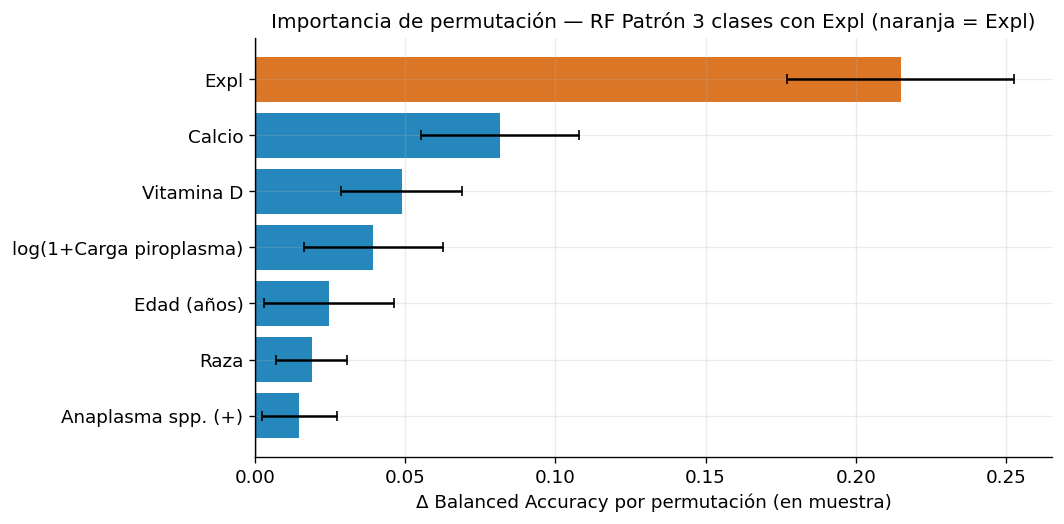

In [26]:
print("Paso 1: Ajustando RF completo (biomarcadores + Expl)...")
full_pipe = make_pipe_3d(FEATURES_ALL).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="accuracy",
    n_repeats=1000,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  FEATURES_ALL,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (biomarcadores + Expl):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
colors_bar = [PALETTE[1] if f == EXPL_COL else PALETTE[0] for f in order.feature]
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=colors_bar, capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF Patrón 3 clases con Expl (naranja = Expl)")
plt.tight_layout(); plt.savefig("figures/fig_03d_perm_importance_full.png"); plt.show()

In [27]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)

bio_imp = imp_df[imp_df.feature != EXPL_COL].sort_values("imp_mean", ascending=True)
elim_order = bio_imp["feature"].tolist()
print(f"Orden de eliminación de biomarcadores: {elim_order}")
print(f"Covariable fija: {EXPL_COL}\n")
print("Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...\n")

current_bio = [f for f in FEATURES_ALL if f != EXPL_COL]  # solo biomarcadores; Expl se añade aparte
history = []

m0, s0 = cv_metrics_3d(current_bio, X_all, y, cv=CV_SEL)
history.append({"n": len(current_bio), "bio_features": current_bio.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_bio):2d} bio + Expl [baseline] BAL_ACC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_bio or len(current_bio) <= 1: break
    test_bio = [f for f in current_bio if f != feat]
    m, s = cv_metrics_3d(test_bio, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_bio), "bio_features": test_bio.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_bio):2d} bio + Expl [-{feat:20s}] BAL_ACC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_bio = test_bio

hist_df = pd.DataFrame(history)

Orden de eliminación de biomarcadores: ['ANAPLASMA', 'RAZA2', 'EDAD', 'PIROPLASMA_Q_log', 'VITAMINA_D', 'CALCIO']
Covariable fija: Expl

Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...

   6 bio + Expl [baseline] BAL_ACC=0.568±0.101
   5 bio + Expl [-ANAPLASMA           ] BAL_ACC=0.574±0.109  Δ=+0.006
   4 bio + Expl [-RAZA2               ] BAL_ACC=0.537±0.089  Δ=-0.031
   3 bio + Expl [-EDAD                ] BAL_ACC=0.563±0.092  Δ=-0.006
   2 bio + Expl [-PIROPLASMA_Q_log    ] BAL_ACC=0.604±0.079  Δ=+0.036
   1 bio + Expl [-VITAMINA_D          ] BAL_ACC=0.616±0.105  Δ=+0.047


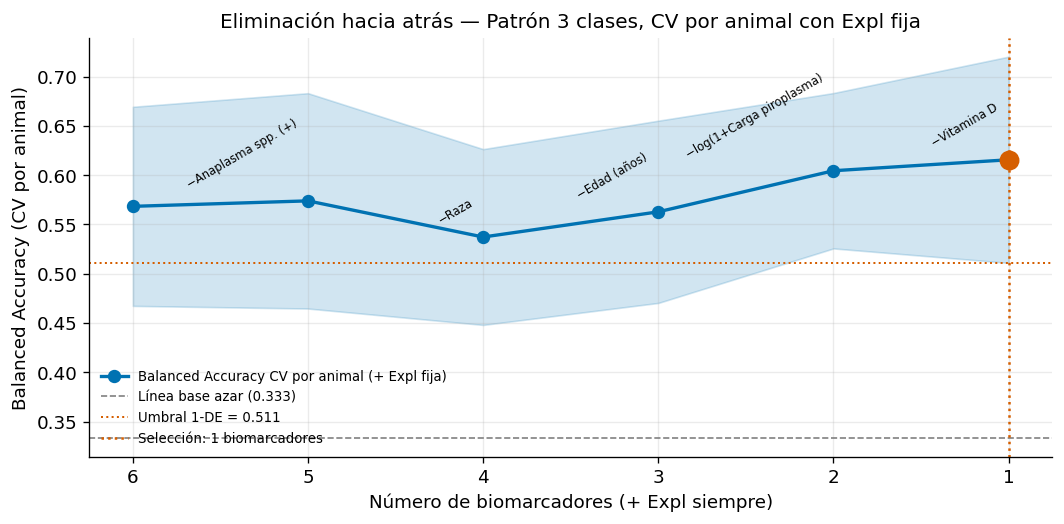


Biomarcadores SELECCIONADOS (1): ['CALCIO']


In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7,
        label="Balanced Accuracy CV por animal (+ Expl fija)")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"],
                alpha=0.18, color=PALETTE[0])
ax.axhline(1/3, ls="--", color="grey", lw=1, label="Línea base azar (0.333)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} biomarcadores")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8), fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de biomarcadores (+ Expl siempre)")
ax.set_ylabel("Balanced Accuracy (CV por animal)")
ax.set_title("Eliminación hacia atrás — Patrón 3 clases, CV por animal con Expl fija")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_03d_feature_selection_curve.png"); plt.show()

SELECTED_BIO_3D = list(parsimonious.bio_features)
print(f"\nBiomarcadores SELECCIONADOS ({len(SELECTED_BIO_3D)}): {SELECTED_BIO_3D}")

Calculando ROC-AUC macro para cada subconjunto (≈1 min)...
   6 bio [-—(baseline)         ] ROC=0.682±0.097
   5 bio [-ANAPLASMA           ] ROC=0.678±0.094
   4 bio [-RAZA2               ] ROC=0.667±0.098
   3 bio [-EDAD                ] ROC=0.687±0.092
   2 bio [-PIROPLASMA_Q_log    ] ROC=0.706±0.083
   1 bio [-VITAMINA_D          ] ROC=0.715±0.099


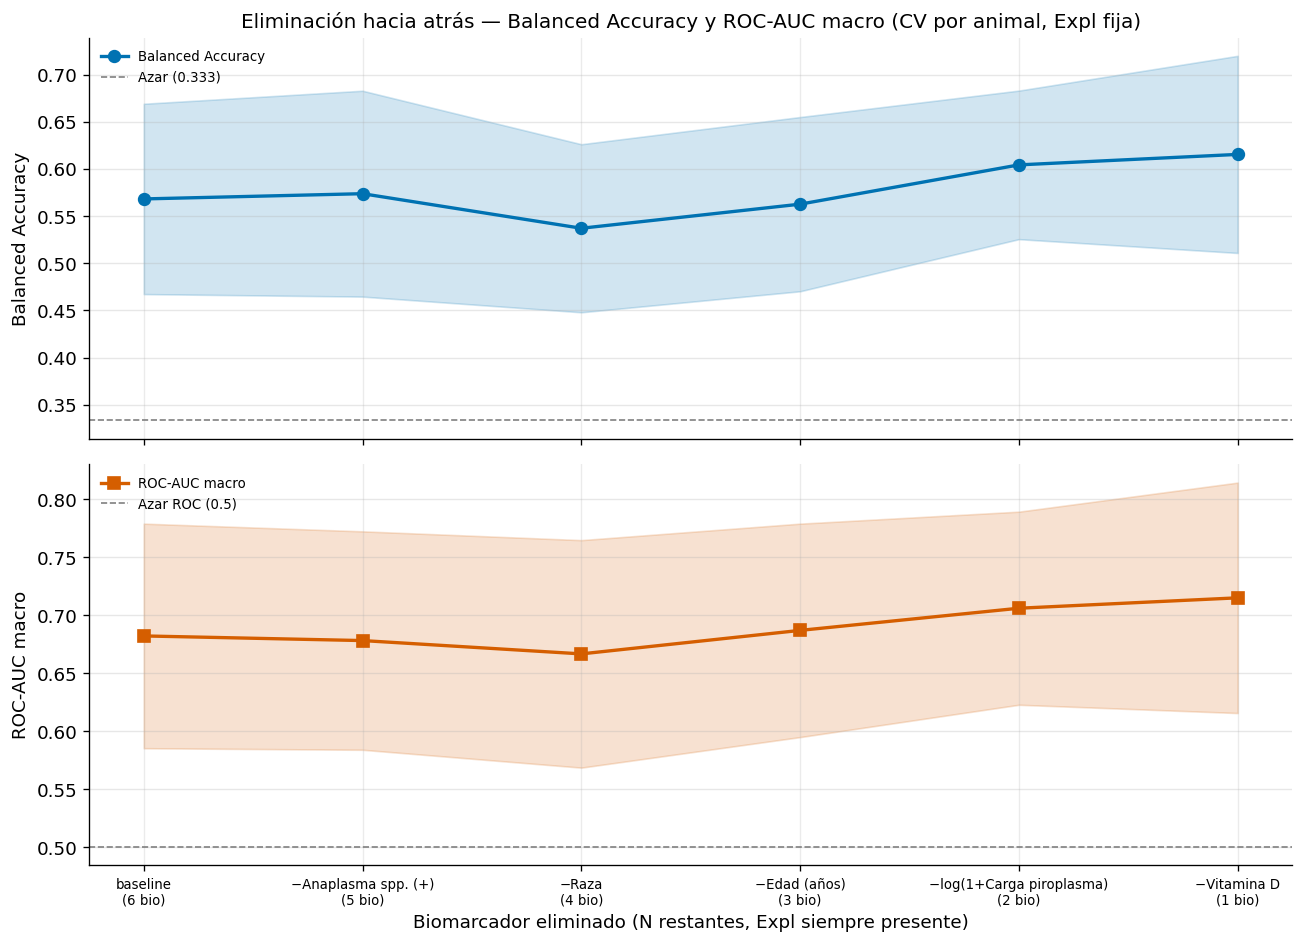

In [29]:
print("Calculando ROC-AUC macro para cada subconjunto (≈1 min)...")
roc_means, roc_stds = [], []
for _, row in hist_df.iterrows():
    feats_tmp = list(row["bio_features"]) + [EXPL_COL]
    Xs_tmp = X_all[feats_tmp]
    pipe_tmpl = make_pipe_3d(feats_tmp)
    rocs = []
    for tr, te in CV_SEL.split(Xs_tmp, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs_tmp.iloc[tr], y[tr])
        p = pf.predict_proba(Xs_tmp.iloc[te])
        try:
            rocs.append(roc_auc_score(y[te], p, multi_class='ovr', average='macro'))
        except Exception:
            rocs.append(np.nan)
    roc_means.append(np.nanmean(rocs))
    roc_stds.append(np.nanstd(rocs))
    print(f"  {int(row.n):2d} bio [-{row['removed']:20s}] ROC={roc_means[-1]:.3f}±{roc_stds[-1]:.3f}")

hist_df = hist_df.assign(roc_mean=roc_means, roc_std=roc_stds)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} bio)"
    else:
        lbl = f"−{tb.PRETTY.get(row['removed'], row['removed'])}\n({int(row.n)} bio)"
    labels.append(lbl)

ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Balanced Accuracy")
ax1.fill_between(x, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax1.axhline(1/3, ls="--", color="grey", lw=1, label="Azar (0.333)")
ax1.set_ylabel("Balanced Accuracy"); ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Eliminación hacia atrás — Balanced Accuracy y ROC-AUC macro (CV por animal, Expl fija)")

ax2 = axes[1]
ax2.plot(x, hist_df["roc_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="ROC-AUC macro")
ax2.fill_between(x, hist_df["roc_mean"]-hist_df["roc_std"], hist_df["roc_mean"]+hist_df["roc_std"], alpha=0.18, color=PALETTE[1])
ax2.axhline(0.5, ls="--", color="grey", lw=1, label="Azar ROC (0.5)")
ax2.set_ylabel("ROC-AUC macro"); ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Biomarcador eliminado (N restantes, Expl siempre presente)")
plt.tight_layout()
plt.savefig("figures/fig_03d_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

### 3.4 PIMP — significancia de la importancia (Altmann et al.)

Método **PIMP** (*Permutation IMPortance*, Altmann et al. 2010): a diferencia de la
importancia de permutación del paso 1 (que permuta cada **feature**), aquí se permuta la
**variable respuesta** `y`, preservando la estructura de correlación entre features. Esto
genera, para cada biomarcador, una distribución nula de la importancia Gini (impureza,
`feature_importances_` del RF) bajo H0 (no hay relación feature–respuesta).

Algoritmo:
1. Entrenar el RF con `X`, `y` originales → importancia Gini observada `GI_b,i` de cada feature `i`.
2. Repetir `n` veces: permutar `y` → `y*`, reentrenar el RF con `(X, y*)`, guardar la Gini `GI_H0,ij`.
3. Para cada feature, estimar la ECDF de `{GI_H0,i1, …, GI_H0,in}` y calcular
   `p-valor_i = P(GI_H0,i ≥ GI_b,i)` (proporción de importancias nulas que igualan o superan la observada).
4. `p-valor < α` ⇒ evidencia de que la feature está asociada a la respuesta.

Las columnas one-hot de una misma feature categórica (`Expl_*`) se suman para obtener la
importancia Gini de la feature original.

In [30]:
N_PERM_PIMP = 1000  # permutaciones de y (Altmann et al. sugieren cientos-miles; ~1-2 min con este n)

def gini_importance_by_feature(pipe, feature_list):
    """Suma la importancia Gini de las columnas one-hot de cada feature original."""
    prep = pipe.named_steps["prep"]
    clf  = pipe.named_steps["clf"]
    names_out = prep.get_feature_names_out()
    raw_imp = clf.feature_importances_
    return {
        feat: raw_imp[[i for i, n in enumerate(names_out)
                       if n == feat or n.startswith(feat + "_")]].sum()
        for feat in feature_list
    }

print("PIMP — Paso 1: importancia Gini observada (modelo base, y original)...")
baseline_pipe_pimp = make_pipe_3d(FEATURES_ALL).fit(X_all, y)
gi_baseline = gini_importance_by_feature(baseline_pipe_pimp, FEATURES_ALL)

rng_pimp = np.random.default_rng(tb.SEED)
gi_null = {f: np.empty(N_PERM_PIMP) for f in FEATURES_ALL}

print(f"PIMP — Paso 2: {N_PERM_PIMP} permutaciones de y + reentrenamiento del RF...")
for j in range(N_PERM_PIMP):
    y_perm = rng_pimp.permutation(y)
    pipe_j = clone(baseline_pipe_pimp).fit(X_all, y_perm)
    gi_j = gini_importance_by_feature(pipe_j, FEATURES_ALL)
    for f in FEATURES_ALL:
        gi_null[f][j] = gi_j[f]

print("PIMP — Paso 3: p-valores empíricos (proporción de importancias nulas ≥ observada)...")
pimp_df = pd.DataFrame([
    dict(feature=f, gi_obs=gi_baseline[f], gi_null_mean=gi_null[f].mean(),
         gi_null_std=gi_null[f].std(),
         p_value=float(np.mean(gi_null[f] >= gi_baseline[f])))
    for f in FEATURES_ALL
]).sort_values("p_value").reset_index(drop=True)
pimp_df["p_fdr"] = tb.fdr(pimp_df["p_value"].values)
pimp_df["pretty"] = pimp_df.feature.map(lambda f: tb.PRETTY.get(f, f))
pimp_df["significativo"] = pimp_df["p_value"] < 0.05

print("\nResultado PIMP (ordenado por p-valor, α=0.05):")
print(pimp_df[["pretty", "gi_obs", "gi_null_mean", "gi_null_std", "p_value", "p_fdr", "significativo"]]
      .round(4).to_string(index=False))

PIMP — Paso 1: importancia Gini observada (modelo base, y original)...
PIMP — Paso 2: 1000 permutaciones de y + reentrenamiento del RF...
PIMP — Paso 3: p-valores empíricos (proporción de importancias nulas ≥ observada)...

Resultado PIMP (ordenado por p-valor, α=0.05):
                 pretty  gi_obs  gi_null_mean  gi_null_std  p_value  p_fdr  significativo
                   Expl  0.3573        0.1080       0.0296    0.000    0.0           True
                   Raza  0.0417        0.0480       0.0225    0.503    1.0          False
     Anaplasma spp. (+)  0.0386        0.0432       0.0155    0.539    1.0          False
            Edad (años)  0.0954        0.1311       0.0258    0.935    1.0          False
             Vitamina D  0.1688        0.2157       0.0321    0.947    1.0          False
log(1+Carga piroplasma)  0.1492        0.2149       0.0305    0.994    1.0          False
                 Calcio  0.1489        0.2390       0.0322    1.000    1.0          False


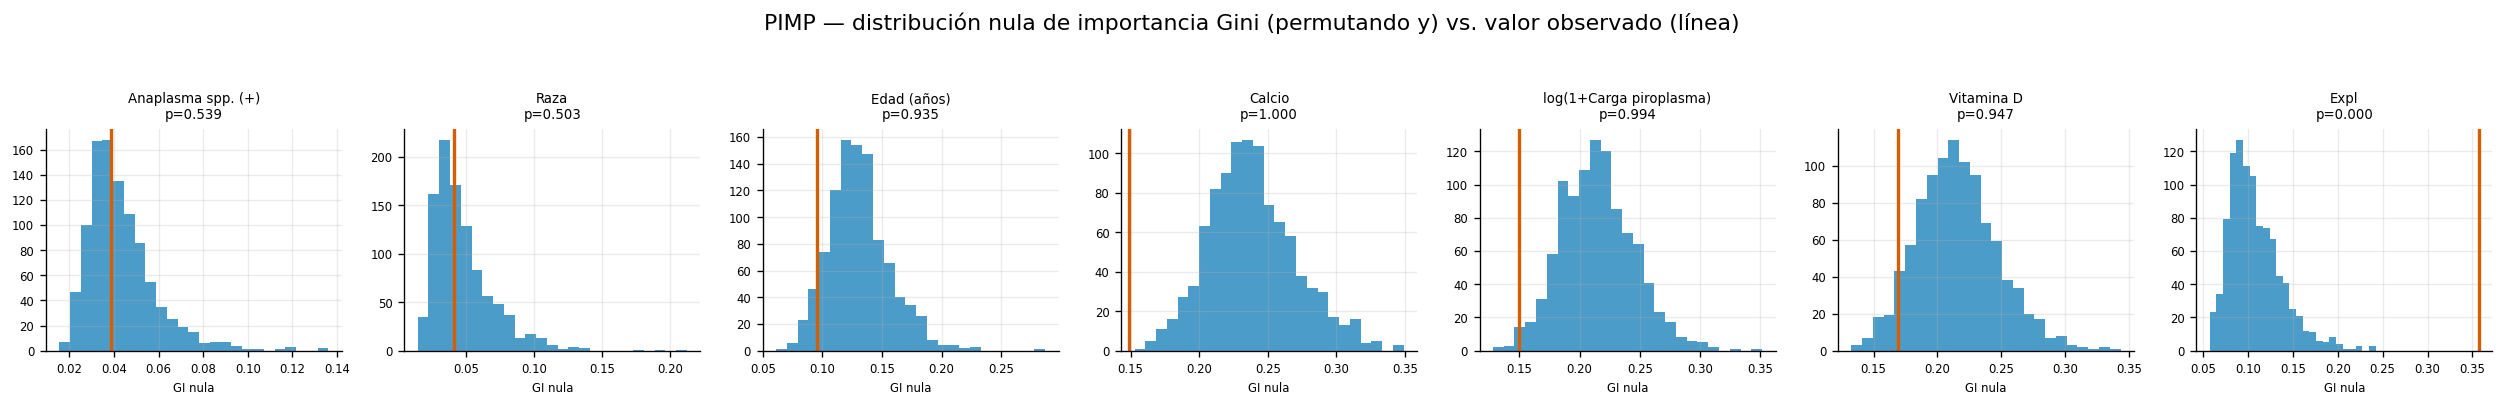

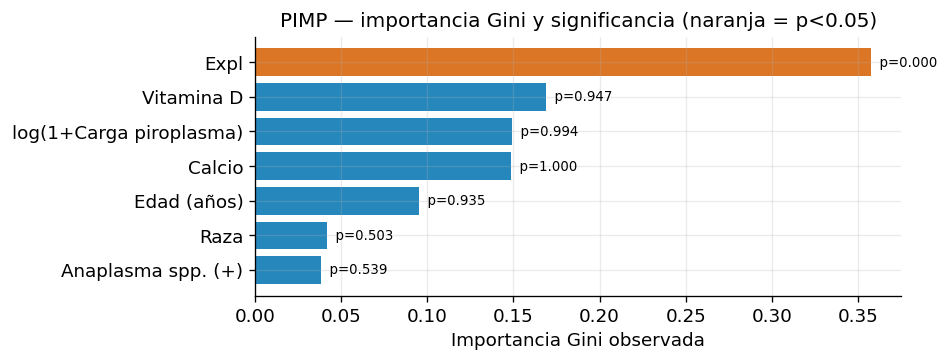

Features significativas (PIMP, p<0.05): ['Expl']


In [31]:
order_feats = pimp_df.sort_values("gi_obs").feature.tolist()
n_f = len(order_feats)
fig, axes = plt.subplots(1, n_f, figsize=(3.0 * n_f, 3.2), sharey=False)
for ax, feat in zip(axes, order_feats):
    row = pimp_df.loc[pimp_df.feature == feat].iloc[0]
    ax.hist(gi_null[feat], bins=25, color=PALETTE[0], alpha=0.7)
    ax.axvline(row.gi_obs, color=PALETTE[1], lw=2)
    ax.set_title(f"{row.pretty}\np={row.p_value:.3f}", fontsize=8)
    ax.set_xlabel("GI nula", fontsize=7); ax.tick_params(labelsize=7)
plt.suptitle("PIMP — distribución nula de importancia Gini (permutando y) vs. valor observado (línea)", y=1.05)
plt.tight_layout(); plt.savefig("figures/fig_03d_pimp_distributions.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * n_f)))
order = pimp_df.sort_values("gi_obs")
colors_bar = [PALETTE[1] if s else PALETTE[0] for s in order.significativo]
ax.barh(order.pretty, order.gi_obs, color=colors_bar, alpha=0.85)
for i, (_, row) in enumerate(order.iterrows()):
    ax.text(row.gi_obs, i, f"  p={row.p_value:.3f}", va="center", fontsize=8)
ax.set_xlabel("Importancia Gini observada")
ax.set_title("PIMP — importancia Gini y significancia (naranja = p<0.05)")
plt.tight_layout(); plt.savefig("figures/fig_03d_pimp_importance.png", bbox_inches="tight"); plt.show()

print(f"Features significativas (PIMP, p<0.05): {pimp_df.loc[pimp_df.significativo, 'feature'].tolist()}")

## 4. Evaluación del modelo final (CV por animal, 5×10)

Modelo final — features (4): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'Expl']

Métricas CV por animal (5×10, con Expl):
  BAL_ACC  = 0.567 ± 0.096   (azar = 0.333)
  ROC mac  = 0.675 ± 0.101   (azar = 0.5)


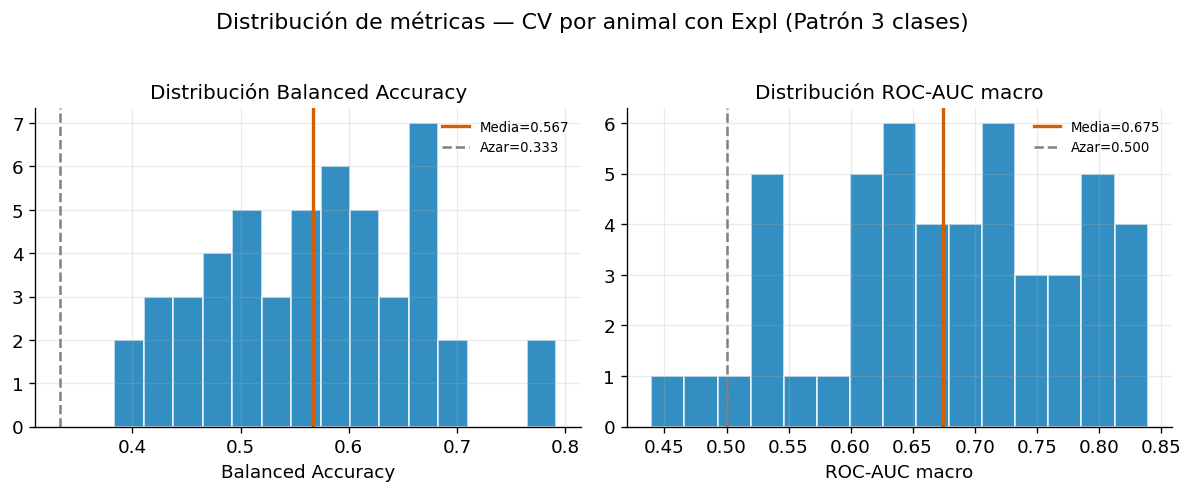

In [21]:
SELECTED_BIO_3D = ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']  # ajustar si procede
FEATS_FINAL_3D = SELECTED_BIO_3D + [EXPL_COL]
Xs = X_all[FEATS_FINAL_3D].copy()
print(f"Modelo final — features ({len(FEATS_FINAL_3D)}): {FEATS_FINAL_3D}\n")

detailed_df = cv_metrics_3d(SELECTED_BIO_3D, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, con Expl):")
print(f"  BAL_ACC  = {m.bal_acc:.3f} ± {s.bal_acc:.3f}   (azar = 0.333)")
print(f"  ROC mac  = {m.roc_mac:.3f} ± {s.roc_mac:.3f}   (azar = 0.5)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title, chance in zip(axes,
                                   ["bal_acc", "roc_mac"],
                                   ["Balanced Accuracy", "ROC-AUC macro"],
                                   [1/3, 0.5]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    ax.axvline(chance, color="grey", ls="--", lw=1.5, label=f"Azar={chance:.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal con Expl (Patrón 3 clases)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_03d_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

SHAP para las 3 clases. Se visualiza especialmente la clase **generalizado** (clase 1).
Las columnas `Expl_*` muestran el efecto granja residual en el modelo.

In [ ]:
FINAL_3D = make_pipe_3d(FEATS_FINAL_3D, n_estimators=500).fit(Xs, y)
print(f"OOB Score (en muestra): {FINAL_3D.named_steps['clf'].oob_score_:.3f}")

prep_3d  = FINAL_3D.named_steps["prep"]
clf_3d   = FINAL_3D.named_steps["clf"]
Xt_3d    = prep_3d.transform(Xs)
names_3d = list(prep_3d.get_feature_names_out())

explainer_3d = shap.TreeExplainer(clf_3d)
shap_vals_3d = explainer_3d.shap_values(Xt_3d)

if isinstance(shap_vals_3d, list):
    sv_d_list = shap_vals_3d
    sv_d_mean = np.mean([np.abs(s) for s in sv_d_list], axis=0)
else:
    arr = np.asarray(shap_vals_3d)
    if arr.ndim == 3:
        sv_d_list = [arr[:, :, i] for i in range(arr.shape[2])]
        sv_d_mean = np.abs(arr).mean(axis=2)
    else:
        sv_d_list = [arr]; sv_d_mean = np.abs(arr)

classes_sorted = np.sort(np.unique(y))
idx_gen = np.where(classes_sorted == 1)[0][0]
sv_d_gen = sv_d_list[idx_gen]

exp_val_3d = (float(explainer_3d.expected_value[idx_gen])
              if isinstance(explainer_3d.expected_value, (list, np.ndarray))
              else float(explainer_3d.expected_value))

print(f"Features tras preprocesamiento : {names_3d}")
print(f"Clases ordenadas               : {classes_sorted}")
print(f"Índice clase generalizado      : {idx_gen}")
print(f"SHAP values generalizado shape : {sv_d_gen.shape}")
print(f"Expected value (clase generalizado): {exp_val_3d:.4f}")

OOB Score (en muestra): 0.534
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'Expl_VA32D', 'Expl_VC30D', 'Expl_VC94C', 'Expl_WZ72B']
Clases ordenadas               : [-1  0  1]
Índice clase generalizado      : 2
SHAP values generalizado shape : (103, 7)
Expected value (clase generalizado): 0.3312


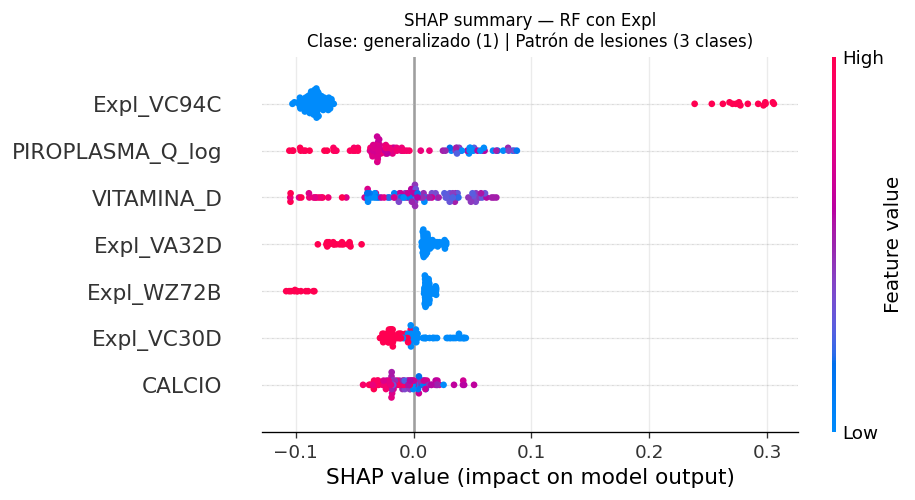

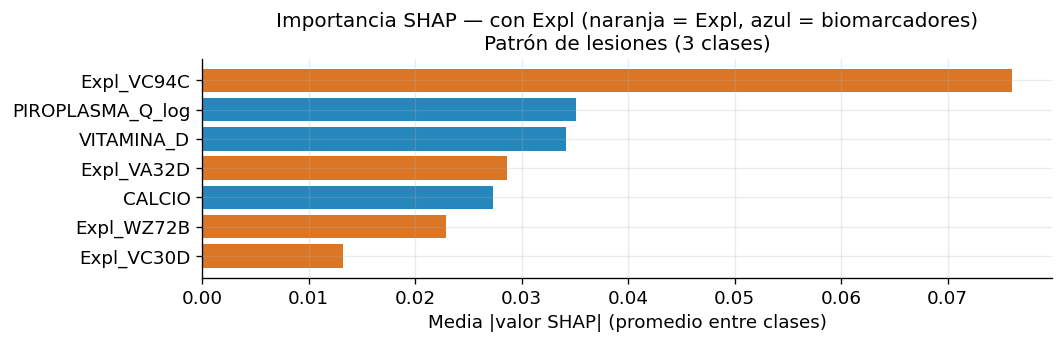

In [ ]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_3d))))
shap.summary_plot(sv_d_gen, Xt_3d, feature_names=names_3d, show=False, max_display=len(names_3d))
plt.title("SHAP summary — RF con Expl\nClase: generalizado (1) | Patrón de lesiones (3 clases)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_03d_shap_summary.png", bbox_inches="tight"); plt.show()

mean_abs_3d = sv_d_mean.mean(0)
si_3d = pd.DataFrame({"feature": names_3d, "mean_abs": mean_abs_3d}).sort_values("mean_abs")
colors_shap = [PALETTE[1] if "Expl" in f else PALETTE[0] for f in si_3d.feature]
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(names_3d))))
ax.barh(si_3d.feature, si_3d.mean_abs, color=colors_shap, alpha=0.85)
ax.set_xlabel("Media |valor SHAP| (promedio entre clases)")
ax.set_title("Importancia SHAP — con Expl (naranja = Expl, azul = biomarcadores)\nPatrón de lesiones (3 clases)")
plt.tight_layout(); plt.savefig("figures/fig_03d_shap_importance.png"); plt.show()

In [ ]:
shap.initjs()
order = np.argsort(FINAL_3D.predict_proba(Xs)[:, idx_gen])
fp = shap.force_plot(exp_val_3d, sv_d_gen[order], Xt_3d[order], feature_names=names_3d)
shap.save_html("figures/fig_03d_shap_force_plot_global.html", fp)
display(fp)

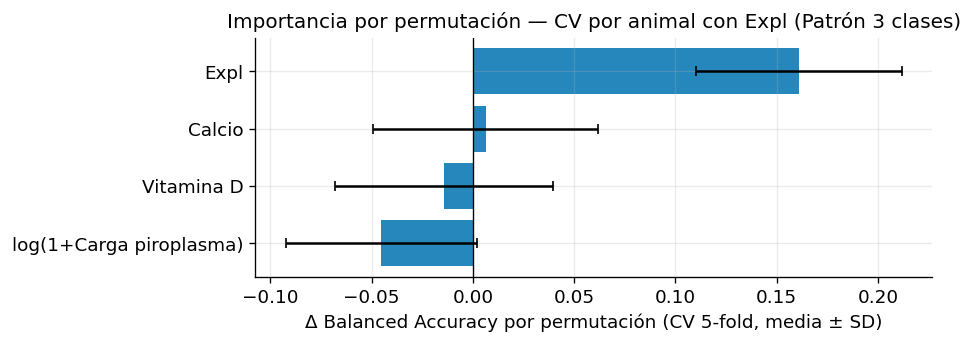

Estabilidad Spearman entre folds: 0.640


In [ ]:
from scipy.stats import spearmanr
imp_runs_3d = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_3d(FEATS_FINAL_3D)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="balanced_accuracy", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_3d.append(pd.Series(pi_f.importances_mean, index=FEATS_FINAL_3D))

imp_mat_3d = pd.concat(imp_runs_3d, axis=1)
imp_ord_3d = imp_mat_3d.mean(axis=1).sort_values().index
R = imp_mat_3d.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(FEATS_FINAL_3D))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_3d],
        imp_mat_3d.mean(axis=1)[imp_ord_3d],
        xerr=imp_mat_3d.std(axis=1)[imp_ord_3d],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal con Expl (Patrón 3 clases)")
plt.tight_layout(); plt.savefig("figures/fig_03d_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


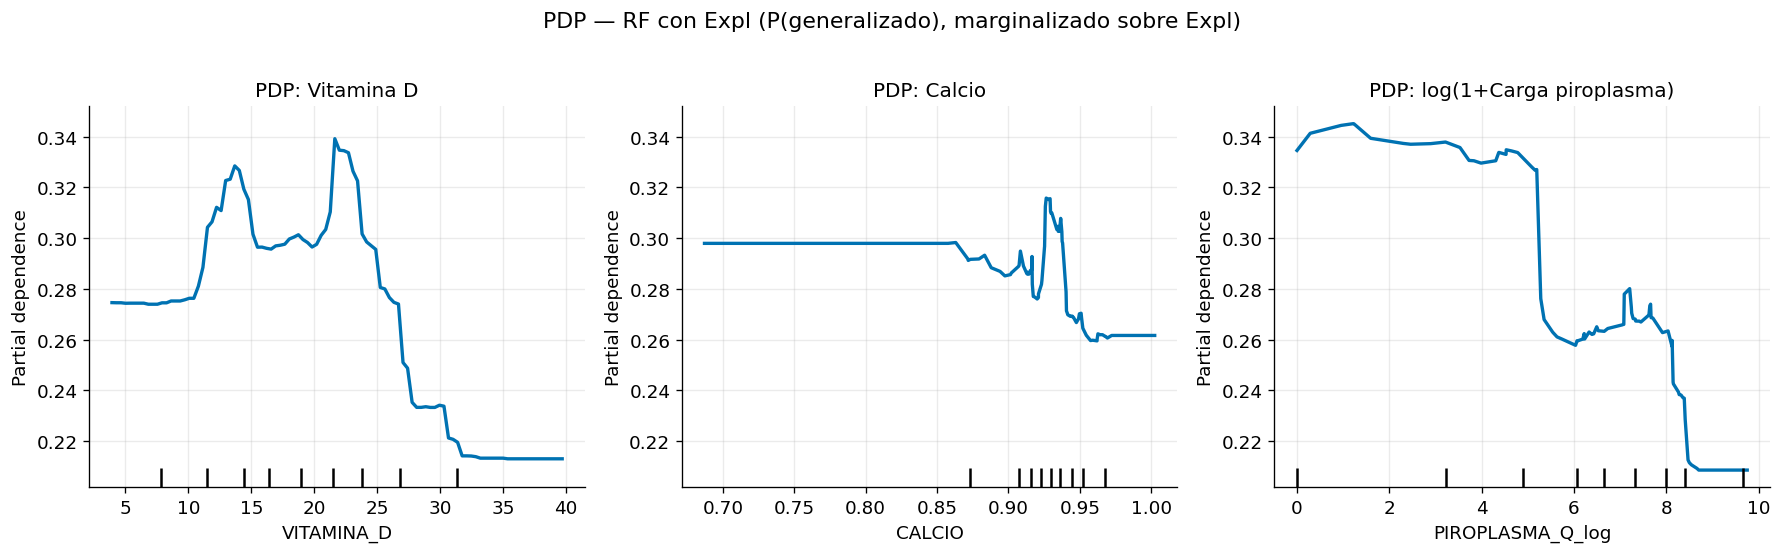

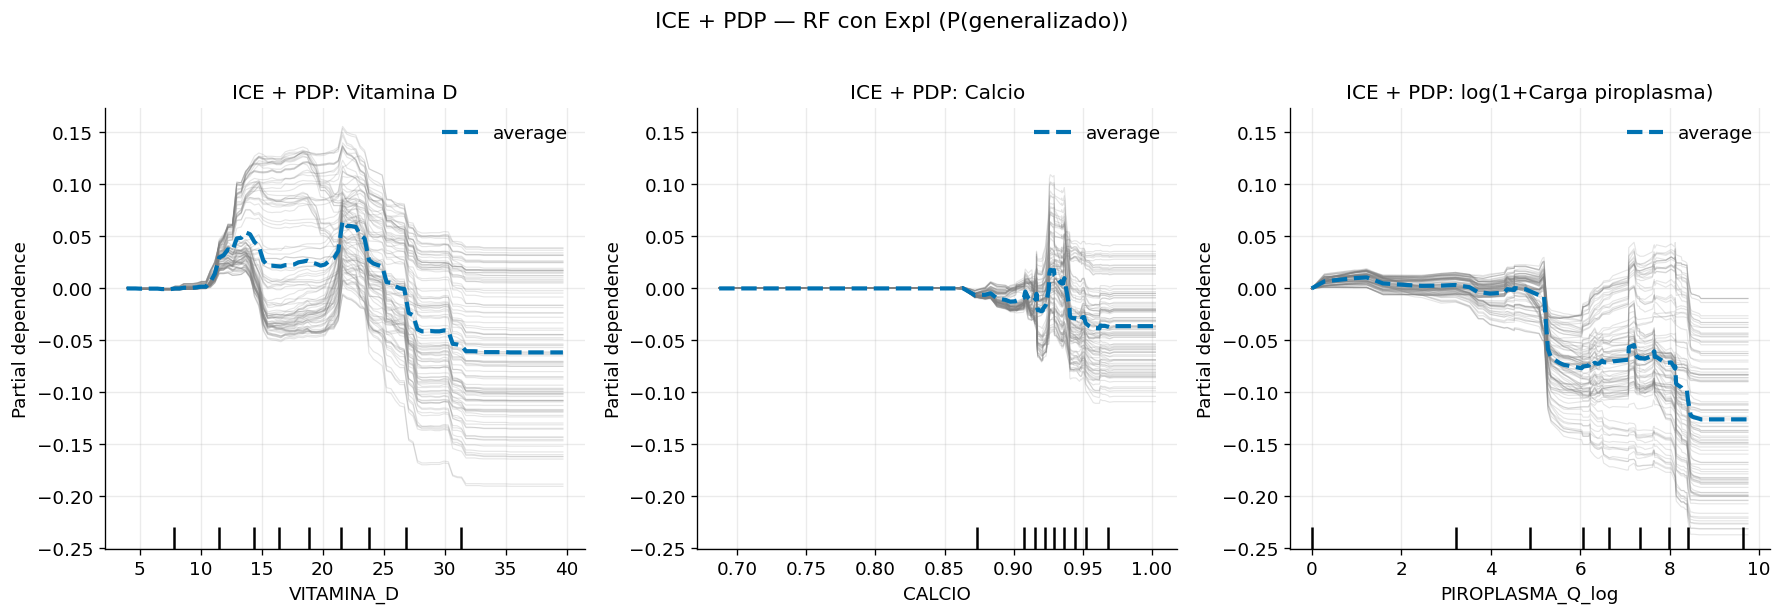

In [ ]:
CONT_3D = [f for f in FEATS_FINAL_3D if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_3D:
    CONT_3D = [f for f in FEATS_FINAL_3D if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_3D}")
if CONT_3D:
    n_c = len(CONT_3D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3D, Xs, CONT_3D, kind="average",
        target=1, ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_3D):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF con Expl (P(generalizado), marginalizado sobre Expl)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3D, Xs, CONT_3D, kind="both",
        target=1, ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_3D):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF con Expl (P(generalizado))", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d_ice.png", bbox_inches="tight"); plt.show()

## 7. Accumulated Local Effects (ALE)

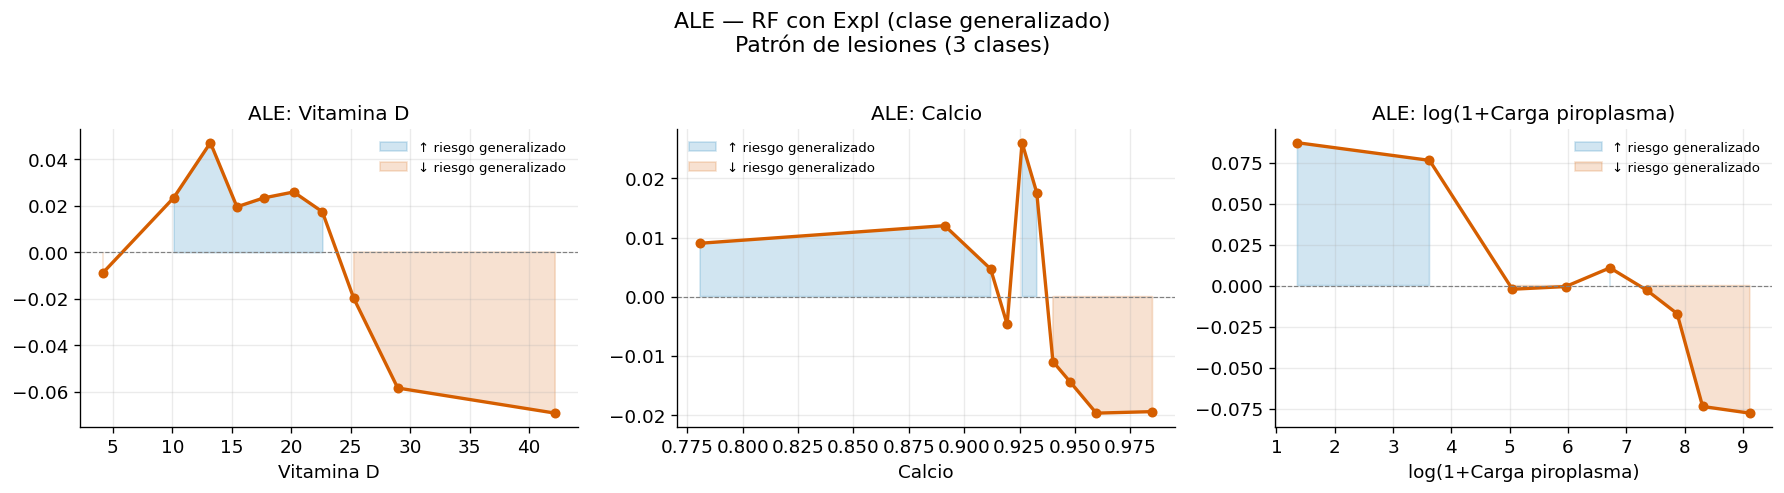

In [ ]:
def ale_1d(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, idx_gen] - model.predict_proba(lo)[:, idx_gen]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_3D:
    n_c = len(CONT_3D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3D):
        cx, ale = ale_1d(FINAL_3D, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo generalizado")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo generalizado")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE — RF con Expl (clase generalizado)\nPatrón de lesiones (3 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d_ale.png", bbox_inches="tight"); plt.show()

## 8. SHAP waterfall — interpretabilidad local

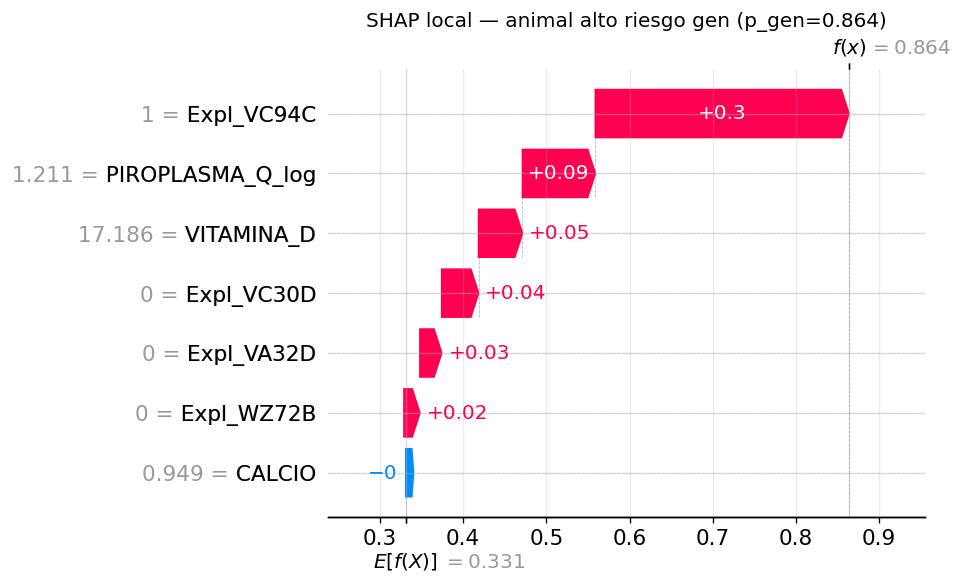

Animal 58: p_gen=0.864, clase real=1, pred=1


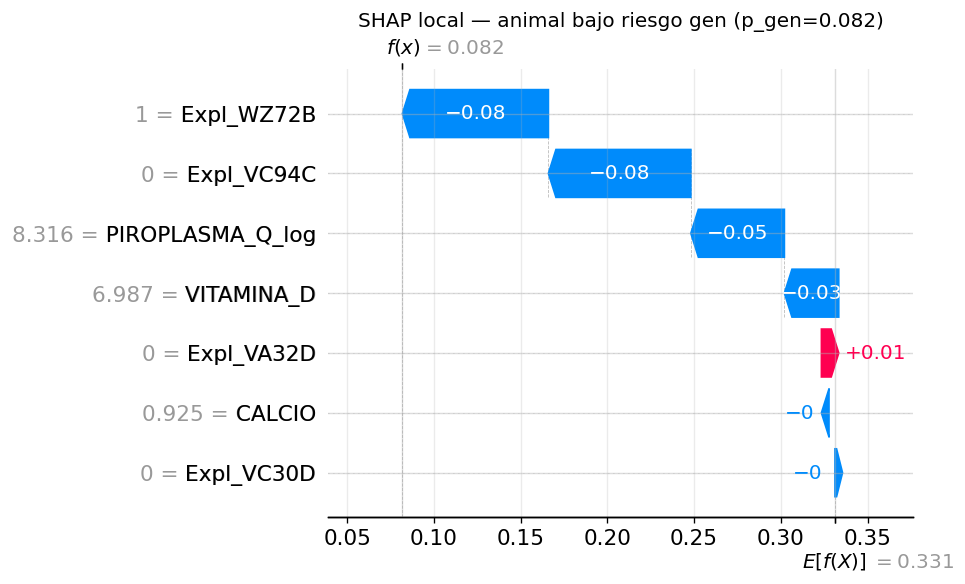

Animal 100: p_gen=0.082, clase real=0, pred=0


In [ ]:
p_gen = FINAL_3D.predict_proba(Xs)[:, idx_gen]
idx_pos = int(np.argmax(p_gen))
idx_neg = int(np.argmin(p_gen))

shap_exp_3d = shap.Explanation(values=sv_d_gen, base_values=exp_val_3d,
                                data=Xt_3d, feature_names=names_3d)

for tag, idx in [("alto_riesgo_gen", idx_pos), ("bajo_riesgo_gen", idx_neg)]:
    fig, _ = plt.subplots(figsize=(10, 4))
    shap.plots.waterfall(shap_exp_3d[idx], max_display=len(names_3d), show=False)
    plt.title(f"SHAP local — animal {tag.replace('_',' ')} (p_gen={p_gen[idx]:.3f})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_03d_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: p_gen={p_gen[idx]:.3f}, clase real={y[idx]}, pred={FINAL_3D.predict(Xs)[idx]}")

## 9. Contrafactuales (sobre biomarcadores, granja fija)

In [ ]:
def find_cf(model, row_dict, feat, lo, hi, target_cls, n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()
target_cls = 1

print("=" * 60)
print("CONTRAFACTUALES — biomarcadores (granja fija, clase generalizado)")
print("=" * 60)
for tag, row, tgt in [("ALTO riesgo gen.", high_row, 0), ("BAJO riesgo gen.", low_row, target_cls)]:
    pred = int(FINAL_3D.predict(pd.DataFrame([row]))[0])
    p    = FINAL_3D.predict_proba(pd.DataFrame([row]))[0, idx_gen]
    print(f"\nAnimal {tag} (predicha={pred}, p_gen={p:.3f}, granja={row[EXPL_COL]}), objetivo → clase {tgt}")
    for feat in CONT_3D:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf = find_cf(FINAL_3D, row.to_dict(), feat, lo_v, hi_v, tgt)
        cur = row[feat]
        if cf is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf:.2f} (Δ={cf-cur:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")

CONTRAFACTUALES — biomarcadores (granja fija, clase generalizado)

Animal ALTO riesgo gen. (predicha=1, p_gen=0.864, granja=VC94C), objetivo → clase 0


In [ ]:
if CONT_3D:
    n_c = len(CONT_3D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3D):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Alto riesgo gen.", high_row, PALETTE[1]),
                                 ("Bajo riesgo gen.", low_row, PALETTE[0])]:
            probs = [FINAL_3D.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, idx_gen] for v in grid]
            ax.plot(grid, probs, color=color, lw=2, label=f"{tag} (granja={row[EXPL_COL]})")
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(1/3, color="grey", ls="--", lw=0.8, label="Azar (0.333)")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("P(generalizado)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=7)
    plt.suptitle("Sensibilidad contrafactual — RF con Expl (granja fija)\nPatrón de lesiones (3 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03d_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis y triangulación

### Tabla comparativa

| Métrica | Nb 2d — CV sin expl (3 cls) | **Nb 3d — CV + Expl fija (3 cls)** |
|---|---|---|
| BAL_ACC | — | **—** |
| ROC-AUC macro | — | **—** |
| CV strategy | RepeatedSKFold | **RepeatedSKFold + Expl feature** |
| Expl como feature | No | **Sí (OHE, siempre fija)** |

### Guía de interpretación

- **Si BAL_ACC(3d) >> BAL_ACC(2d):** la explotación aporta señal incremental para predecir
  el patrón lesional más allá de los biomarcadores solos.

- **Si BAL_ACC(3d) ≈ BAL_ACC(2d):** la identidad de la granja no añade valor predictivo
  para el patrón lesional; los biomarcadores capturan toda la señal disponible.

- **SHAP de Expl_*:** si las columnas de granja tienen SHAP elevado para la clase
  generalizado, el patrón lesional está fuertemente determinado por la granja
  (diferencias en cepa, presión de infección o manejo).